# Energy Analysis

The scHopfield energy functional decomposes into three biologically interpretable

components:



$$E = E_{\text{interaction}} + E_{\text{degradation}} + E_{\text{bias}}$$



- **E_interaction**: Energy stored in gene–gene regulatory interactions

- **E_degradation**: Energy stored in mRNA decay terms

- **E_bias**: Energy stored in external input / basal expression bias



Lower total energy ≈ more stable attractor state.  This notebook shows how to

compute, visualise, and interpret these energies.

## Setup

In [1]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scHopfield as sch

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Assumes the model was saved in notebook 01
DATA_PATH  = './scratch/Data/'
DATASET_FILE = 'hematopoiesis.h5ad'
MODEL_FILE = 'model.h5sch'

CLUSTER_KEY = 'cell_type'
SPLICED_KEY  = 'M_t'

CELL_TYPE_ORDER = ['Meg', 'Ery', 'MEP-like', 'HSC', 'GMP-like', 'Mon', 'Bas', 'Neu']

adata = sc.read_h5ad(DATA_PATH + DATASET_FILE)
adata = sch.tl.load_model(adata, MODEL_FILE)
print(adata)


/home/bernaljp/miniconda3/envs/SCH/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/tmp/ipykernel_1221845/3037205977.py:23: UserWarning: adata has 1956 genes but the model was trained on 1728.  A subsetted copy is being returned; the original adata is NOT modified.  Reassign the return value:
    adata = sch.tl.load_model(adata, filename)
  adata = sch.tl.load_model(adata, MODEL_FILE)


Model loaded from 'model.h5sch'  |  clusters=['Bas', 'Ery', 'GMP-like', 'HSC', 'MEP-like', 'Meg', 'Mon', 'Neu', 'all']  |  genes=1728
AnnData object with n_obs × n_vars = 1947 × 1728
    obs: 'batch', 'time', 'cell_type', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'new_Size_Factor', 'initial_new_cell_size', 'total_Size_Factor', 'initial_total_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'Size_Factor', 'initial_cell_size', 'ntr', 'cell_cycle_phase', 'leiden', 'control_point_pca', 'inlier_prob_pca', 'obs_vf_angle_pca', 'pca_ddhodge_div', 'pca_ddhodge_potential', 'acceleration_pca', 'curvature_pca', 'n_counts', 'mt_frac', 'jacobian_det_pca', 'manual_selection', 'divergence_pca', 'curv_leiden', 'curv_louvain', 'SPI1->GATA1_jacobian', 'jacobian', 'umap_ori_leiden', 'umap_ori_louvain', 'umap_ddhodge_div', 'umap_ddhodge_potential', 'curl_umap', 'divergence_umap', 'acceleration_umap', 'control_point_umap_ori', '

## 2.1 Compute & Decompose Energies

In [2]:
sch.tl.compute_energies(adata, cluster_key=CLUSTER_KEY, spliced_key=SPLICED_KEY)

# Inspect stored energy columns
energy_cols = ['energy_total', 'energy_interaction', 'energy_degradation', 'energy_bias']
print(adata.obs[energy_cols].describe())


       energy_total  energy_interaction  energy_degradation  energy_bias
count   1947.000000         1947.000000         1947.000000  1947.000000
mean       0.465193           -6.238026            6.703232    -0.000013
std        2.017105            4.142948            2.293970     0.000014
min       -8.506401          -22.371951            3.737046    -0.000058
25%        0.257570           -7.225530            4.937362    -0.000021
50%        1.199007           -4.855515            6.226903    -0.000014
75%        1.606413           -3.356720            7.367836    -0.000005
max        2.778031           -1.868195           14.112776     0.000053


In [3]:
# Summary statistics per cell type (including coefficient of variation)
summary = adata.obs[[CLUSTER_KEY] + energy_cols].groupby(CLUSTER_KEY).describe()
for energy in energy_cols:
    summary[(energy, 'cv')] = summary[(energy, 'std')] / summary[(energy, 'mean')]

print("\nTotal energy statistics:")
print(summary['energy_total'].round(3))



Total energy statistics:
           count   mean    std    min    25%    50%    75%    max     cv
cell_type                                                               
Bas        177.0 -0.475  1.625 -4.416 -1.506 -0.197  0.840  2.274 -3.419
Ery        234.0  0.538  0.726 -1.788  0.057  0.502  1.054  2.369  1.349
GMP-like   161.0  1.386  0.306  0.547  1.190  1.391  1.593  2.092  0.221
HSC        309.0  1.433  0.374  0.309  1.227  1.465  1.663  2.383  0.261
MEP-like   457.0  1.659  0.350  0.224  1.430  1.656  1.871  2.778  0.211
Meg        154.0 -4.099  2.206 -8.506 -5.636 -4.294 -2.506  0.812 -0.538
Mon        423.0  0.672  0.888 -1.749  0.173  0.757  1.325  2.478  1.322
Neu         32.0 -6.661  1.309 -7.924 -7.730 -7.065 -6.085 -3.137 -0.196


## 2.2 Energy Boxplots by Cell Type

In [4]:
adata

AnnData object with n_obs × n_vars = 1947 × 1728
    obs: 'batch', 'time', 'cell_type', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'new_Size_Factor', 'initial_new_cell_size', 'total_Size_Factor', 'initial_total_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'Size_Factor', 'initial_cell_size', 'ntr', 'cell_cycle_phase', 'leiden', 'control_point_pca', 'inlier_prob_pca', 'obs_vf_angle_pca', 'pca_ddhodge_div', 'pca_ddhodge_potential', 'acceleration_pca', 'curvature_pca', 'n_counts', 'mt_frac', 'jacobian_det_pca', 'manual_selection', 'divergence_pca', 'curv_leiden', 'curv_louvain', 'SPI1->GATA1_jacobian', 'jacobian', 'umap_ori_leiden', 'umap_ori_louvain', 'umap_ddhodge_div', 'umap_ddhodge_potential', 'curl_umap', 'divergence_umap', 'acceleration_umap', 'control_point_umap_ori', 'inlier_prob_umap_ori', 'obs_vf_angle_umap_ori', 'curvature_umap_ori', 'energy_total', 'energy_interaction', 'energy_degradation', 'ene

/home/bernaljp/packages/scHopfield/scHopfield/plotting/energy.py:204: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/home/bernaljp/packages/scHopfield/scHopfield/plotting/energy.py:204: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/home/bernaljp/packages/scHopfield/scHopfield/plotting/energy.py:204: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/home/bernaljp/packages/scHopfield/scHopfield/plotting/energy.py:204: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


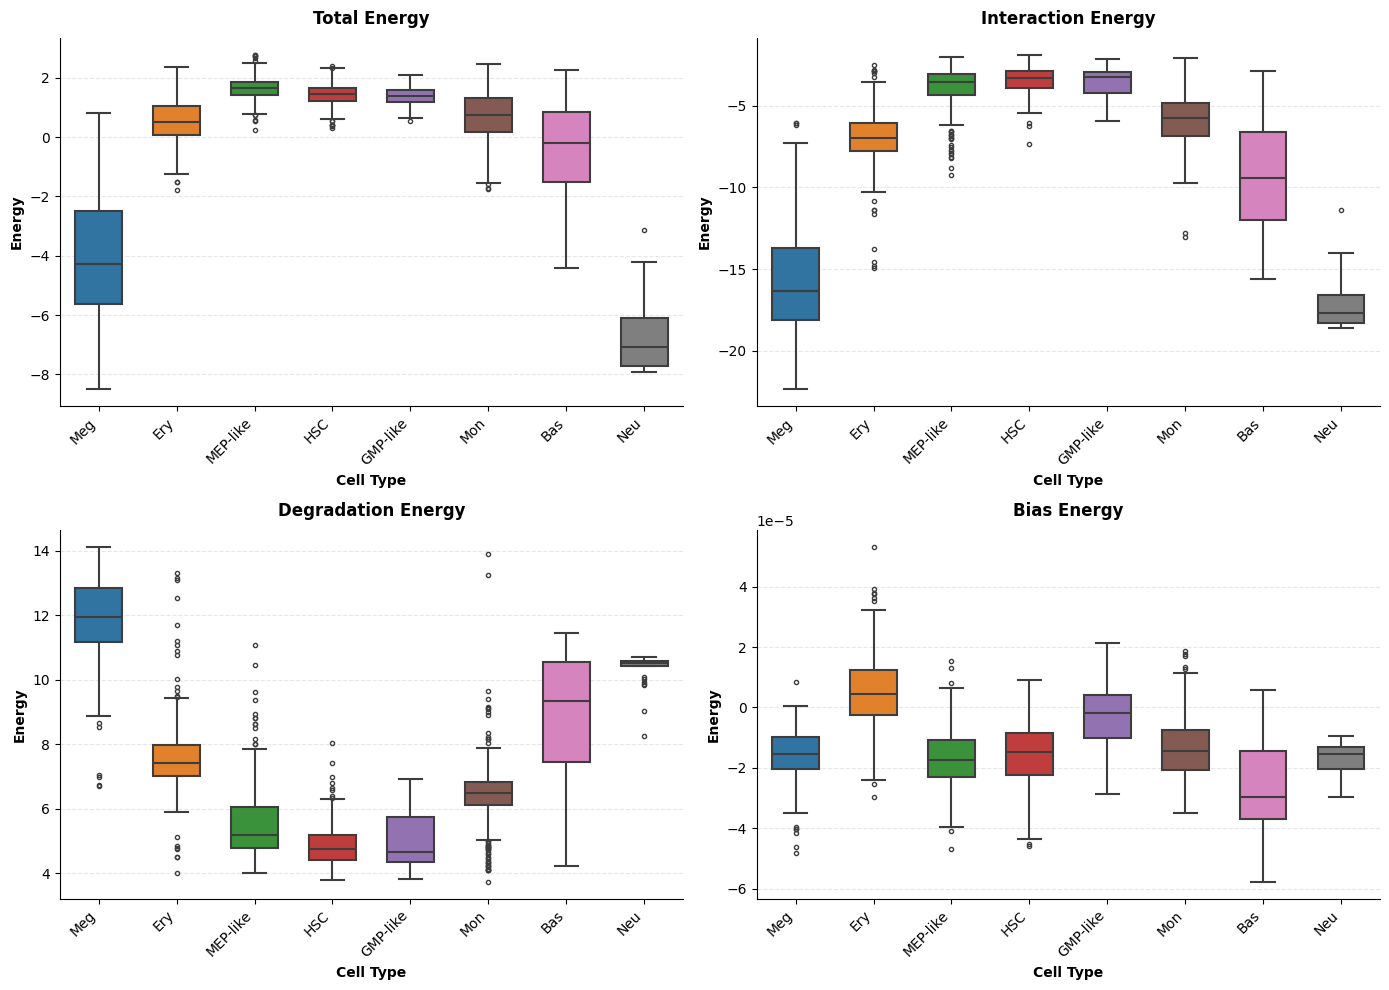

In [5]:
# Retrieve cell-type colours from the dataset (or define your own dict)
# colors = {ct: f'C{i}' for i, ct in enumerate(CELL_TYPE_ORDER)}
colors = dict(zip(CELL_TYPE_ORDER, adata.uns['cell_type_colors']))

# All four energy components
sch.pl.plot_energy_boxplots(
    adata,
    cluster_key=CLUSTER_KEY,
    order=CELL_TYPE_ORDER,
    colors=colors
)
plt.show()


/home/bernaljp/packages/scHopfield/scHopfield/plotting/energy.py:204: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


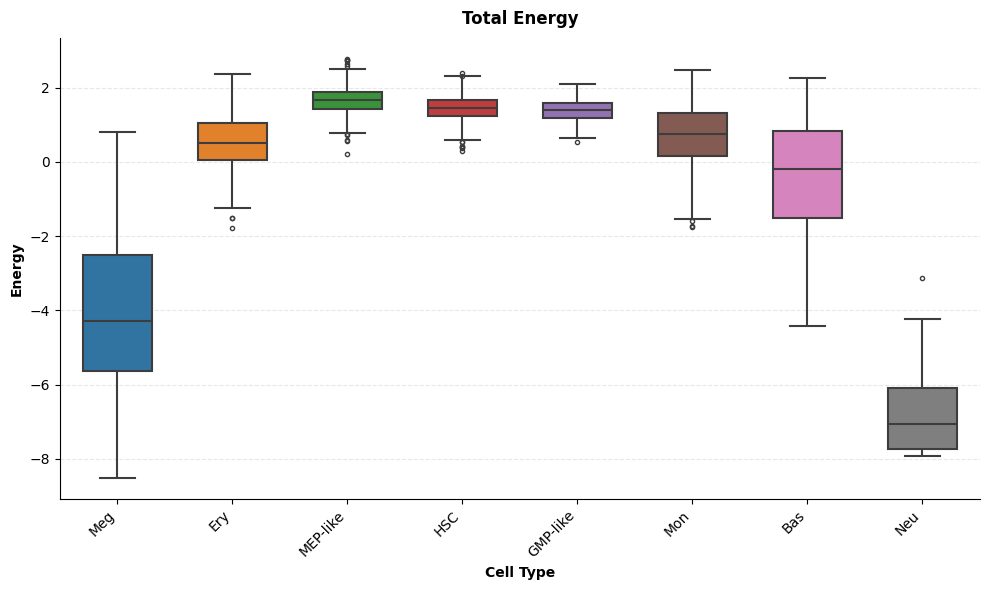

In [6]:
# Total energy only
sch.pl.plot_energy_boxplots(
    adata,
    cluster_key=CLUSTER_KEY,
    plot_energy='total',
    order=CELL_TYPE_ORDER,
    colors=[colors[k] for k in CELL_TYPE_ORDER]
)
plt.show()


## 2.3 Energy on UMAP

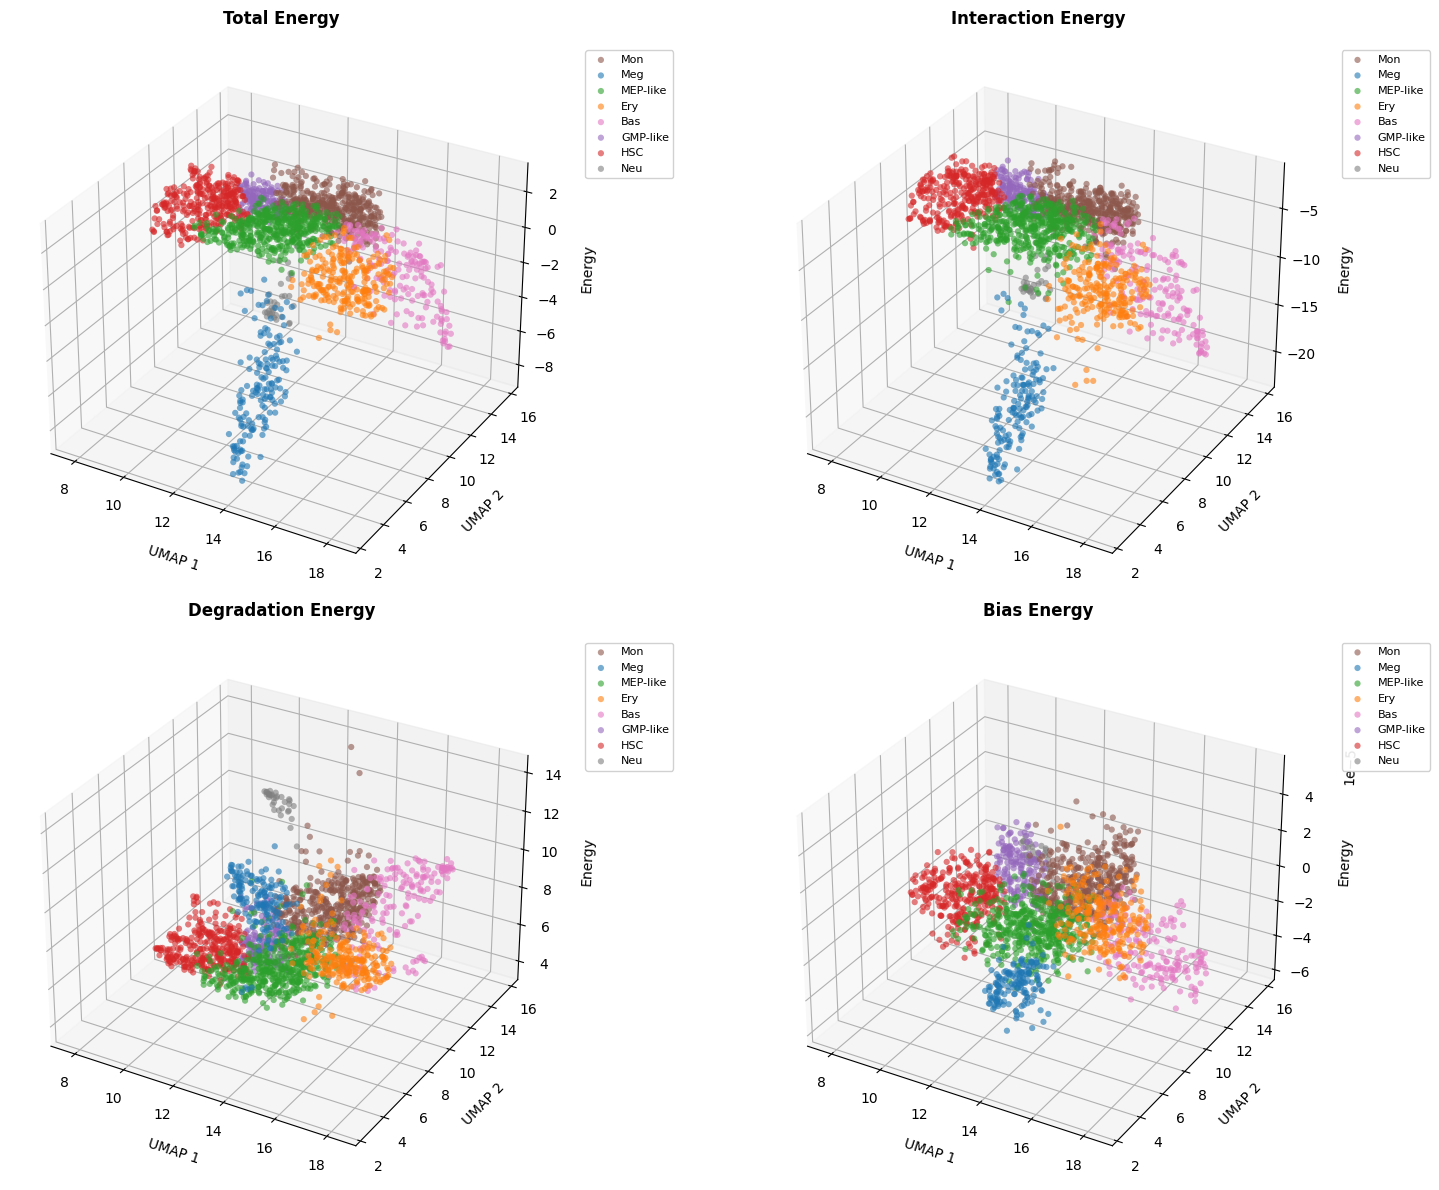

In [7]:
# Scatter plots of each energy component overlaid on UMAP embedding
sch.pl.plot_energy_scatters(
    adata,
    cluster_key=CLUSTER_KEY,
    basis='umap',
    show_legend=True,
    colors=colors,
)
plt.show()


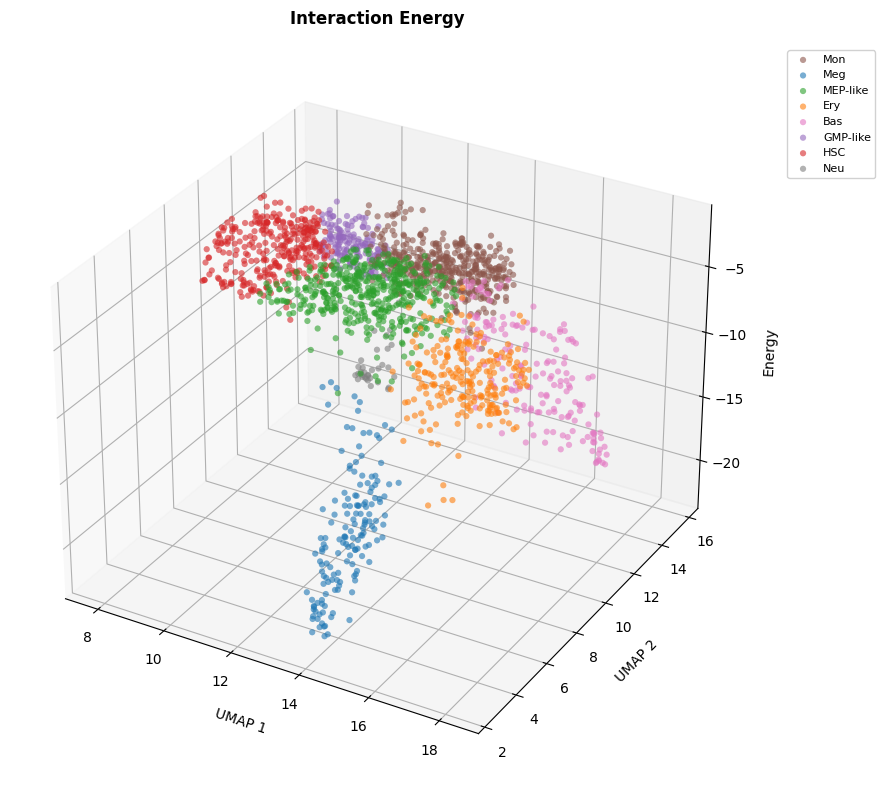

In [8]:
# Interaction energy only
sch.pl.plot_energy_scatters(
    adata,
    cluster_key=CLUSTER_KEY,
    plot_energy='interaction',
    colors=colors,
)
plt.show()


## 2.4 Energy–Gene Correlations



Identifies which genes drive energy differences across cell types.

In [9]:
sch.tl.energy_gene_correlation(
    adata,
    spliced_key=SPLICED_KEY,
    cluster_key=CLUSTER_KEY
)

# Tabulate top correlated genes
df_correlations = sch.tl.get_correlation_table(
    adata,
    cluster_key=CLUSTER_KEY,
    energy_type='total',
    n_top_genes=100,
    order=CELL_TYPE_ORDER
)
df_correlations.head(10)


/home/bernaljp/miniconda3/envs/SCH/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/bernaljp/miniconda3/envs/SCH/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/bernaljp/miniconda3/envs/SCH/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/bernaljp/miniconda3/envs/SCH/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/bernaljp/miniconda3/envs/SCH/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/bernaljp/miniconda3/envs/SCH/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered i

Meg                     Ery             MEP-like                  HSC  \
     Gene Correlation        Gene Correlation     Gene Correlation     Gene   
0     FBL    0.807304       FABP5    0.665676   PRSS57    0.315137  CCDC137   
1    PHB2    0.778194        CD33    0.650139   IL17RB    0.307605     NOP9   
2   ZNRF1    0.775508      RASSF2    0.641904     CHD3    0.284941    FUCA2   
3  RPL18A    0.748102  PALM2AKAP2    0.618501    RAB20    0.280315     SOD2   
4   HMGB3    0.744607       IL2RG    0.611712     PEX6    0.279536    PTCD1   
5   RPL35    0.731323       SATB1    0.597738   RASSF2    0.272160    COTL1   
6  RPUSD4    0.723665      MBOAT7    0.560575     SRGN    0.269023    PSEN1   
7  RECQL4    0.713247        DBN1    0.556944     USE1    0.268064   RECQL4   
8   EIF3K    0.710026  AC244502.1    0.550963    CEBPA    0.266089   MFSD2B   
9   HPGDS    0.703534      LPCAT2    0.549897  CEACAM1    0.259691    DDX41   

                 GMP-like                  Mon                 Bas  \
  Correlation        Gene Correlation     Gene Correlation    Gene   
0    0.482047      CITED2    0.434898     ELF1    0.649138    EXO1   
1    0.436700      ITGA2B    0.412077  HERC2P9    0.563224   FABP5   
2    0.425116      FCER1A    0.400928    TOP2A    0.536342    PHB2   
3    0.425081         HDC    0.399843    KANTR    0.532998  RPL18A   
4    0.420303  AL157895.1    0.384206    STAT3    0.531445    ARV1   
5    0.393799        CPA3    0.371276     ASPM    0.526317  MFSD2B   
6    0.387846       DDIT4    0.370603  HERC2P3    0.515384   DDX41   
7    0.387596       GATA2    0.369129     CD34    0.507963     FBL   
8    0.384711       HPGDS    0.366681    CASP7    0.504359     GPI   
9    0.379453       ZFPM1    0.366653      RDX    0.500153    APRT   

                  Neu              
  Correlation    Gene Correlation  
0    0.807626     FBL    0.900663  
1    0.742007     ERG    0.882317  
2    0.725082   ACSS1    0.868937  
3    0.711273    GFI1    0.866927  
4    0.693583  KLHDC2    0.861760  
5    0.679917  POLR1C    0.840239  
6    0.675017    AQP3    0.826446  
7    0.672615    ASPM    0.824554  
8    0.672221   ERCC6    0.823418  
9    0.667679   INKA1    0.822812

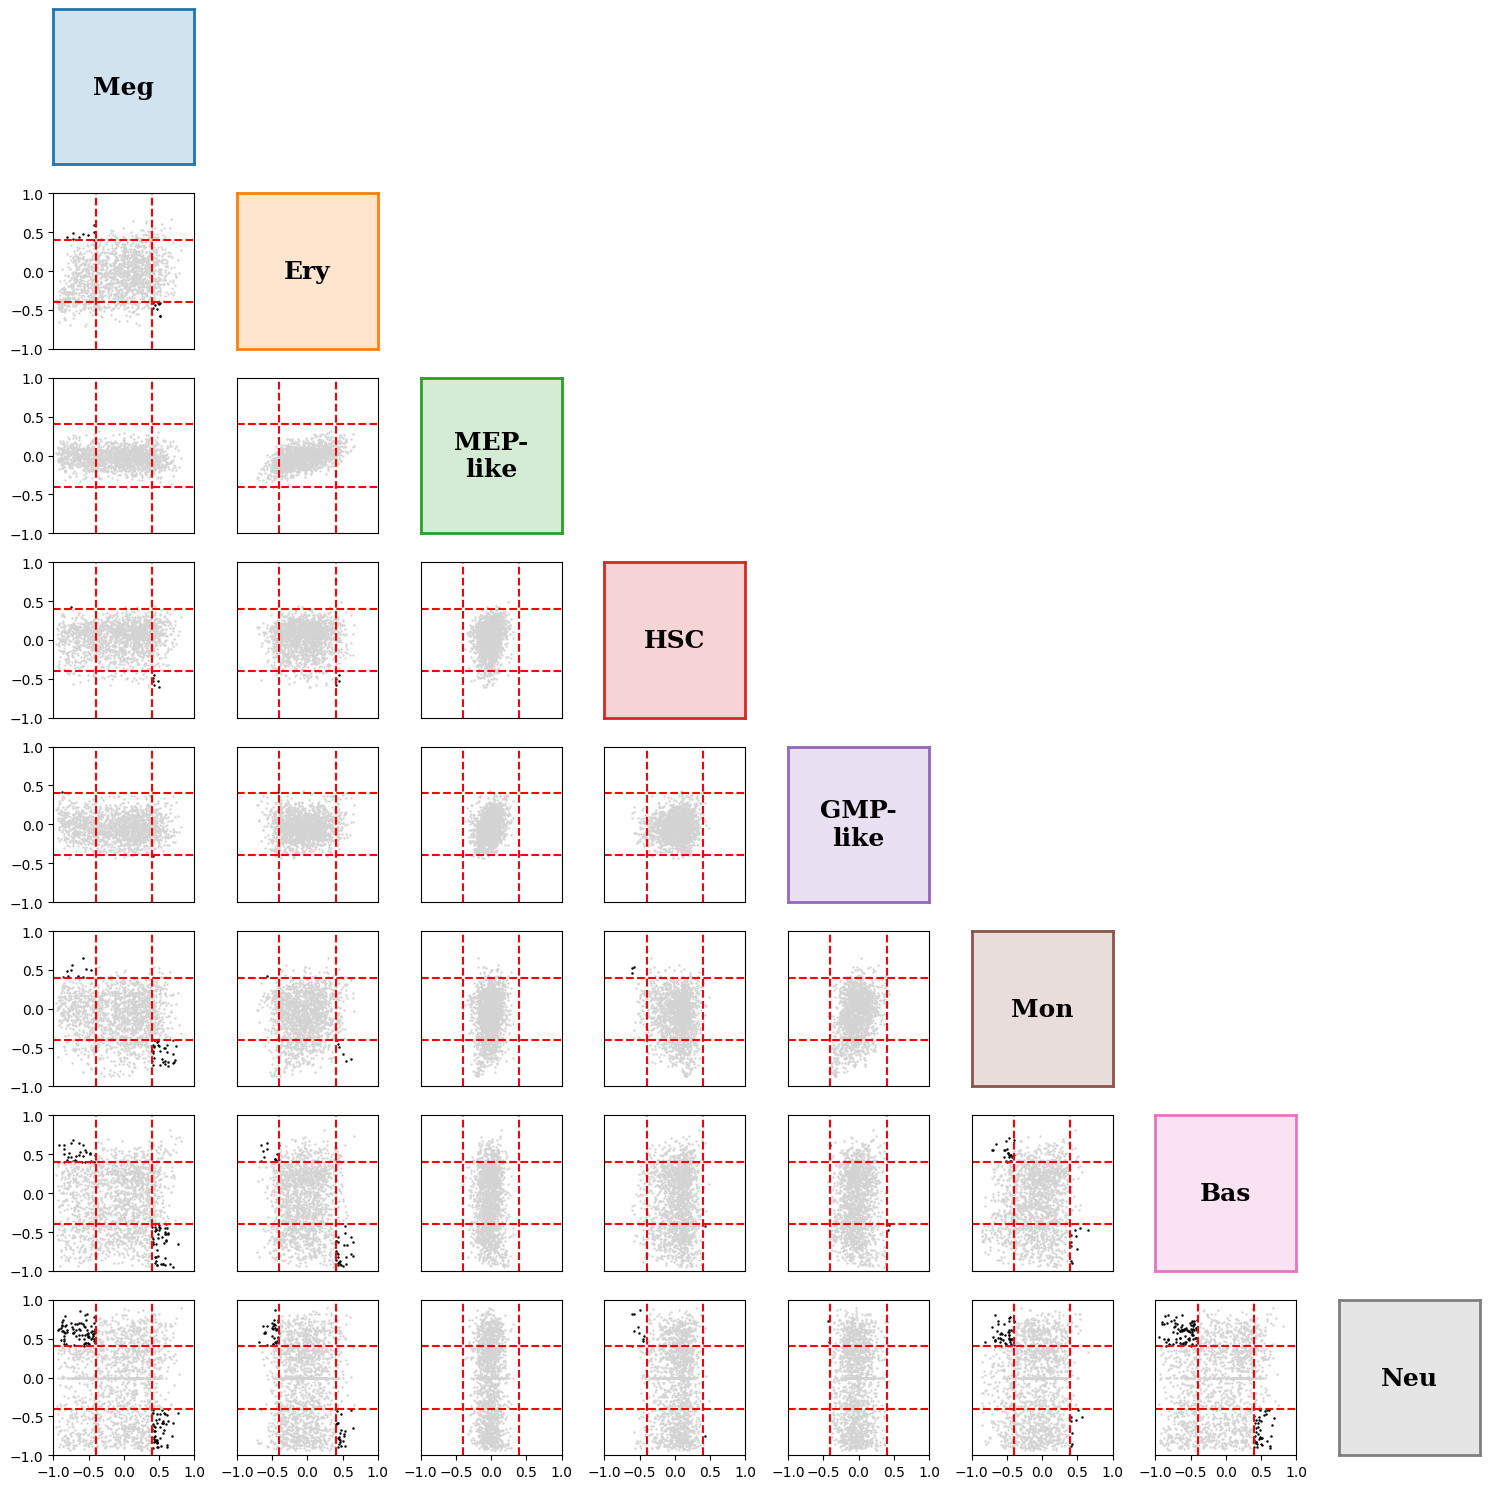

In [10]:
# Pairwise scatter plots (all combinations of cell-type pairs)
sch.pl.plot_correlations_grid(
    adata,
    cluster_key=CLUSTER_KEY,
    energy='total',
    order=CELL_TYPE_ORDER,
    colors=colors,
    x_low=-0.4, x_high=0.4,
    y_low=-0.4, y_high=0.4
)
plt.show()


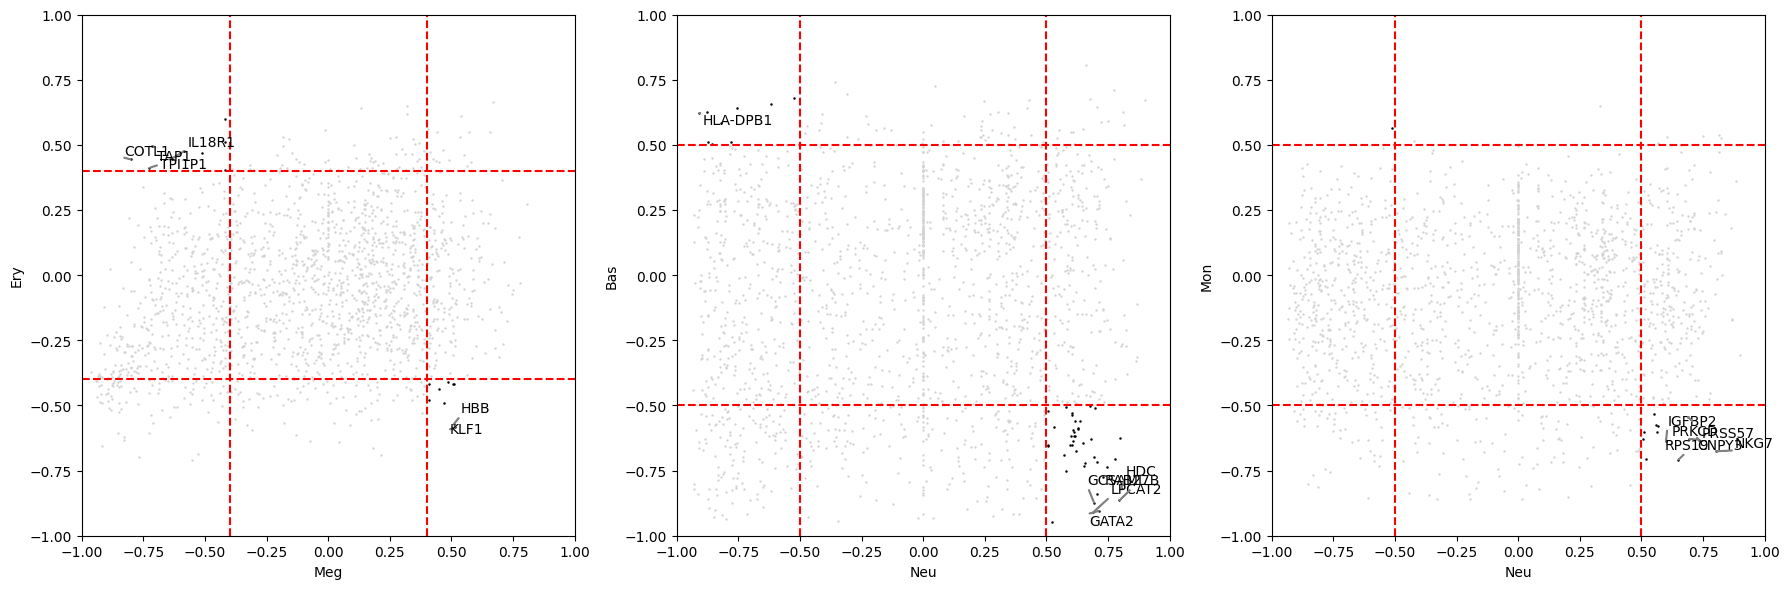

In [11]:
# Highlight specific cell-type pairs
fig, ax = plt.subplots(1, 3, figsize=(18, 6), tight_layout=True)

sch.pl.plot_gene_correlation_scatter(
    adata, 'Meg', 'Ery',
    cluster_key=CLUSTER_KEY, energy='total',
    annotate=6, ax=ax[0],
    clus1_low=-0.4, clus1_high=0.4,
    clus2_low=-0.4, clus2_high=0.4
)
sch.pl.plot_gene_correlation_scatter(
    adata, 'Neu', 'Bas',
    cluster_key=CLUSTER_KEY, energy='total',
    annotate=6, ax=ax[1]
)
sch.pl.plot_gene_correlation_scatter(
    adata, 'Neu', 'Mon',
    cluster_key=CLUSTER_KEY, energy='total',
    annotate=6, ax=ax[2]
)
plt.show()


## 2.5 Corner Gene Identification



"Corner genes" have high-magnitude correlation with one cell type and opposing

(or low) correlation with another — these are candidate lineage-specific

regulatory genes.

In [12]:
genes_mask  = sch._utils.io.get_genes_used(adata)
gene_names  = adata.var.index[genes_mask]

# Build per-cluster correlation arrays
correlation = {}
for cluster in CELL_TYPE_ORDER:
    col = f'correlation_total_{cluster}'
    if col in adata.var.columns:
        correlation[cluster] = adata.var[col].values[genes_mask]

# Thresholds for "corner" classification
clus1_low  = -0.4
clus1_high =  0.4
clus2_low  = -0.4
clus2_high =  0.4
nn = 5   # top-n genes per pair

corner_genes = np.array([])

for corr1, corr2 in itertools.combinations(CELL_TYPE_ORDER, 2):
    if corr1 not in correlation or corr2 not in correlation:
        continue

    c1 = correlation[corr1]
    c2 = correlation[corr2]

    mask_corner = np.logical_or(
        np.logical_and(c1 >= clus1_high, c2 <= clus2_low),
        np.logical_and(c1 <= clus1_low,  c2 >= clus2_high)
    )

    idxs = np.where(mask_corner)[0]
    top  = np.argsort(c1[idxs] ** 2 + c2[idxs] ** 2)[-nn:]
    corner_genes = np.concatenate((corner_genes, gene_names[idxs[top]]))

corner_genes = np.unique(corner_genes)
print(f"Found {len(corner_genes)} corner genes:")
print(corner_genes)


Found 54 corner genes:
['ACSS1' 'AHNAK' 'ARL6IP5' 'ASPM' 'AURKA' 'AURKAIP1' 'CENPE' 'CITED2'
 'CNPY3' 'CORO1A' 'COTL1' 'CPA3' 'CYBA' 'E2F4' 'EIF3K' 'FUCA2' 'GATA2'
 'GCSAML' 'GFI1' 'HDC' 'HEMGN' 'HERC5' 'HLA-DMA' 'HLA-DPB1' 'HLA-DQB1'
 'HLA-DRB6' 'HPGDS' 'IL18R1' 'IL2RG' 'ITGA2B' 'KLF1' 'LMO2' 'LPCAT2'
 'LTBP1' 'NKG7' 'PF4' 'PRICKLE1' 'RAB27B' 'RABGGTA' 'RASSF2' 'RPL35'
 'RPS19' 'RPS21' 'SEMA7A' 'SLC1A4' 'SNCA' 'SOD2' 'STON2' 'SUN2' 'TAP1'
 'TMEM273' 'TOP2A' 'TPI1P1' 'ZNF263']


In [13]:
# Visualise corner gene correlation table
df_corr_corners = pd.DataFrame.from_dict(correlation, orient='columns')
df_corr_corners.index = gene_names
df_corr_corners = df_corr_corners.loc[corner_genes]
df_corr_corners.round(3)


,Meg,Ery,MEP-like,HSC,GMP-like,Mon,Bas,Neu
ACSS1,0.060,-0.467,-0.204,0.066,-0.304,-0.172,-0.109,0.869
AHNAK,0.553,0.461,0.199,0.076,0.077,-0.282,-0.917,-0.715
ARL6IP5,-0.787,0.108,0.236,-0.213,0.037,0.427,-0.398,-0.858
ASPM,0.504,0.024,-0.071,-0.603,0.142,0.526,-0.211,0.825
AURKA,0.417,-0.009,-0.038,-0.529,0.079,0.316,0.100,-0.411
AURKAIP1,0.622,-0.169,-0.110,-0.099,0.095,-0.733,-0.517,-0.563
CENPE,0.361,0.040,-0.100,-0.605,0.081,0.463,-0.168,0.410
CITED2,-0.396,-0.062,-0.013,0.089,0.435,0.187,-0.408,-0.041
CNPY3,0.275,0.206,0.015,0.289,-0.127,-0.633,-0.486,0.734
CORO1A,0.401,0.545,0.218,-0.072,-0.128,-0.674,-0.319,-0.059
